First, load in the necessary packages

In [1]:
# Load in the packages
import numpy as np
# Set up matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from astropy.io import fits
import astropy.wcs as WCS
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
# Set up scipy
from scipy.optimize import curve_fit



Filename: /Users/Matylda/Documents/final_data/asteroid/r/PIRATE_165718_OSL_ROE_Asteroids_2_00_Belgica_00_Filter_R_00_2025_10_09_21_34_07.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    1082   (2048, 2048)   int16 (rescales to uint16)   


[[1399 1399 1399 ... 1399 1399 1399]
 [1399 1399 1399 ... 1399 1399 1399]
 [1399 1399 1399 ... 1399 1399 1399]
 ...
 [1399 1399 1399 ... 1399 1399 1399]
 [1399 1399 1399 ... 1399 1399 1399]
 [1399 1399 1399 ... 1399 1399 1399]]


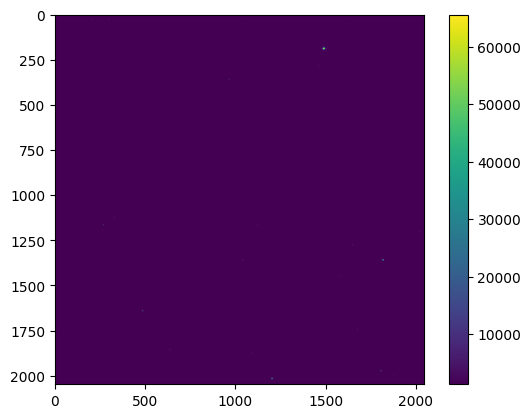

In [2]:
# Load in the image files from three separate nights

image_files = ["/Users/Matylda/Documents/final_data/asteroid/r/PIRATE_165718_OSL_ROE_Asteroids_2_00_Belgica_00_Filter_R_00_2025_10_09_21_34_07.fits",
               "/Users/Matylda/Documents/final_data/asteroid/r/PIRATE_167140_OSL_ROE_Asteroids_2_00_Belgica_00_Filter_R_00_2025_10_19_20_56_12.fits",
               "/Users/Matylda/Documents/final_data/asteroid/r/PIRATE_167827_OSL_ROE_Asteroids_2_00_Belgica_00_Filter_R_00_2025_10_22_19_48_43.fits"]

# Open the FITS file
hdul = fits.open(image_files[0])
hdul.info()

image_data = hdul[0].data

print(image_data)

plt.imshow(image_data)
plt.colorbar()
plt.show()

In [17]:
wcs = WCS.WCS(hdul[0].header)
#print(wcs)

t_obs = hdul[0].header['DATE-OBS']
print(t_obs)

# Get the pixel in julian days 


times = []
times_utc = []

for i in range(len(image_files)):
    hdul = fits.open(image_files[i])
    t_obs = hdul[0].header['DATE-OBS']
    times_utc.append(t_obs)
    t_obs_jd = Time(t_obs, format='isot', scale='utc').jd
    times.append(t_obs_jd)

print(times_utc)


2025-10-22T19:48:43.5988862
['2025-10-09T21:34:07.7287975', '2025-10-19T20:56:12.5418947', '2025-10-22T19:48:43.5988862']


a floating-point value was expected. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


In [20]:
# Convert to days from utc format to fractional days 

obs_1 = 9 + (21 + 34/60 + 7/3600)/24
obs_2 = 19 + (20 + 56/60 + 12/3600)/24
obs_3 = 22 + (19 + 48/60 + 43/3600)/24

frac_days = [obs_1, obs_2, obs_3]
print(f"{float(frac_days[0]):.5f}, {float(frac_days[1]):.5f}, {float(frac_days[2]):.5f}")

9.89869, 19.87236, 22.82550


In [29]:
# Get the pixel coordinates of r-filter captures from across the three nights 

xCoords = [994.328, 1049.31, 1038.99]
yCoords = [1011.69, 980.556, 980.556]
pixel_coords = np.array([[xCoords, yCoords]])
ra, dec = wcs.wcs_pix2world(xCoords, yCoords, 1)

# Get a list of RA and Dec values for the three nights

ra_list = []
dec_list = []

for i in range(len(image_files)):
    hdul = fits.open(image_files[i])
    wcs = WCS.WCS(hdul[0].header)
    pixel_coords = np.array([[xCoords[i], yCoords[i]]])
    world_coords = wcs.wcs_pix2world(pixel_coords, 1)
    ra = world_coords[0][0]
    dec = world_coords[0][1]
    ra_list.append(ra)
    dec_list.append(dec)

# Convert RA and Dec to hour angles 

ra_dec = SkyCoord(ra=ra_list*u.degree, dec=dec_list*u.degree, frame='icrs')

RA_hms = ra_dec.ra.to_string(unit=u.hourangle, sep=':',pad=True, precision=1) # format hms

Dec_dms = ra_dec.dec.to_string(unit=u.degree, sep=':',pad=True, precision=1) # format dms

print(RA_hms)
print(Dec_dms)


print(f"RA: {ra_list}, Dec: {dec_list}")

['23:09:19.3' '23:06:18.4' '23:06:01.0']
['-14:43:46.8' '-14:35:28.6' '-14:28:00.0']
RA: [347.3303746536821, 346.5765643177048, 346.5039775030589], Dec: [-14.729670105902304, -14.591278288648487, -14.466643048716383]


a floating-point value was expected. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


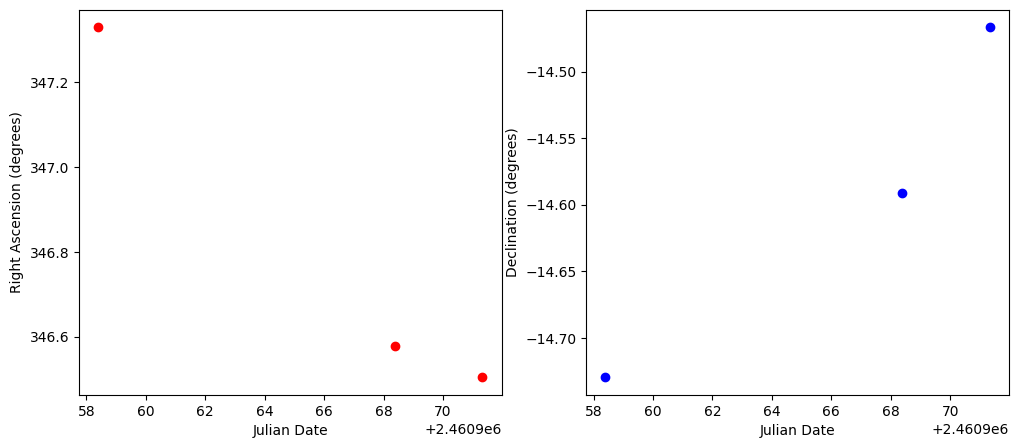

In [5]:
# Now we have the times, RA, and Dec from across three different nights
# We can use these to fit the orbital parameters of the asteroid 

# Plot the observed RA and Dec separately over time
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(times, ra_list, color='red', label='Observed RA')
axes[0].set_ylabel('Right Ascension (degrees)')
axes[0].set_xlabel('Julian Date')

axes[1].scatter(times, dec_list, color='blue', label='Observed Dec')
axes[1].set_ylabel('Declination (degrees)')
axes[1].set_xlabel('Julian Date')



plt.show()



# Now, solve for the orbital elements

In [12]:
import poliastro
import orbitdeterminator
from orbitdeterminator.kep_determination import gauss_method as gm
from astropy.coordinates import EarthLocation, solar_system_ephemeris, get_body_barycentric

In [30]:
# I ended up using Find Orb to determine the orbital elements, which turned out to be
"""
Orbital elements:  Belgica
   Perihelion 2026 Feb 2.94719 +/- 0.557 TT = 22:43:57 (JD 2461074.44719)
Epoch 2025 Oct 22.0 TT = JDT 2460970.5   Earth MOID: 0.8665      Find_Orb
M 341.17589135 +/- 2.7              (J2000 ecliptic)
n   0.18109299 +/- 0.0254           Peri.  319.06671 +/- 4.2
a   3.09410427 +/- 0.289            Node    89.08185 +/- 1.9
e   0.4009427 +/- 0.072             Incl.    4.81440 +/- 0.016
P   5.44255         
q 1.85354564 +/- 0.0498    Q 4.33466289 +/- 0.628
From 3 observations 2025 Oct. 9-22; mean residual 2".3e-003

"""
# State vector (heliocentric equatorial J2000):
#   +2.015169155654  +0.162182741735  -0.114503432586 AU
#   -3.717936293361 +12.269471314763  +5.680615232292 mAU/day
# MOIDs: Me  1.537369 Ve  1.131194 Ea  0.866488 Ma  0.374781
# MOIDs: Ju  1.081878 Sa  5.514233 Ur 14.236196 Ne 25.994952
# 1 oppositions
# Elements written: 13 Jan 2026 11:59:51 (JD 2461053.999898)
# Full range of obs: 2025 Oct. 9-22 (3 observations)
# Find_Orb ver: 2025 Nov 24
# Perturbers: 00000000 (unperturbed orbit);  not using JPL DE
# Tisserand relative to Jupiter: 3.08957
# Score: -0.199335
#  $Name=Belgica  $Ty=2026  $Tm=02  $Td=02.947192  $MA=341.17589
#  $ecc=0.4009427  $Eqnx=2000.
#  $a=3.0941043  $Peri=319.06671  $Node=89.08185  $Incl=4.81440
#  $EpJD=2460970.500  $q=1.853546  $T=2461074.447193  $H=0.0
# Sigmas avail: 1


'\nOrbital elements:  Belgica\n   Perihelion 2026 Feb 2.94719 +/- 0.557 TT = 22:43:57 (JD 2461074.44719)\nEpoch 2025 Oct 22.0 TT = JDT 2460970.5   Earth MOID: 0.8665      Find_Orb\nM 341.17589135 +/- 2.7              (J2000 ecliptic)\nn   0.18109299 +/- 0.0254           Peri.  319.06671 +/- 4.2\na   3.09410427 +/- 0.289            Node    89.08185 +/- 1.9\ne   0.4009427 +/- 0.072             Incl.    4.81440 +/- 0.016\nP   5.44255         \nq 1.85354564 +/- 0.0498    Q 4.33466289 +/- 0.628\nFrom 3 observations 2025 Oct. 9-22; mean residual 2".3e-003\n\n'